In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [20]:
df = pd.read_csv("data.csv", parse_dates=["Date"], dayfirst=True)
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1981-01-02,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,1981-01-05,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,1981-01-06,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,1981-01-07,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,1981-01-08,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


In [21]:
df = df.set_index("Date")
df = df.sort_index()

print("Period covered:", df.index.min().date(), " = ", df.index.max().date())
print("Number of records:", len(df))
df.head()

Period covered: 1981-01-02  =  2023-01-27
Number of records: 10608


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1981-01-02,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1981-01-05,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
1981-01-06,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
1981-01-07,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
1981-01-08,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


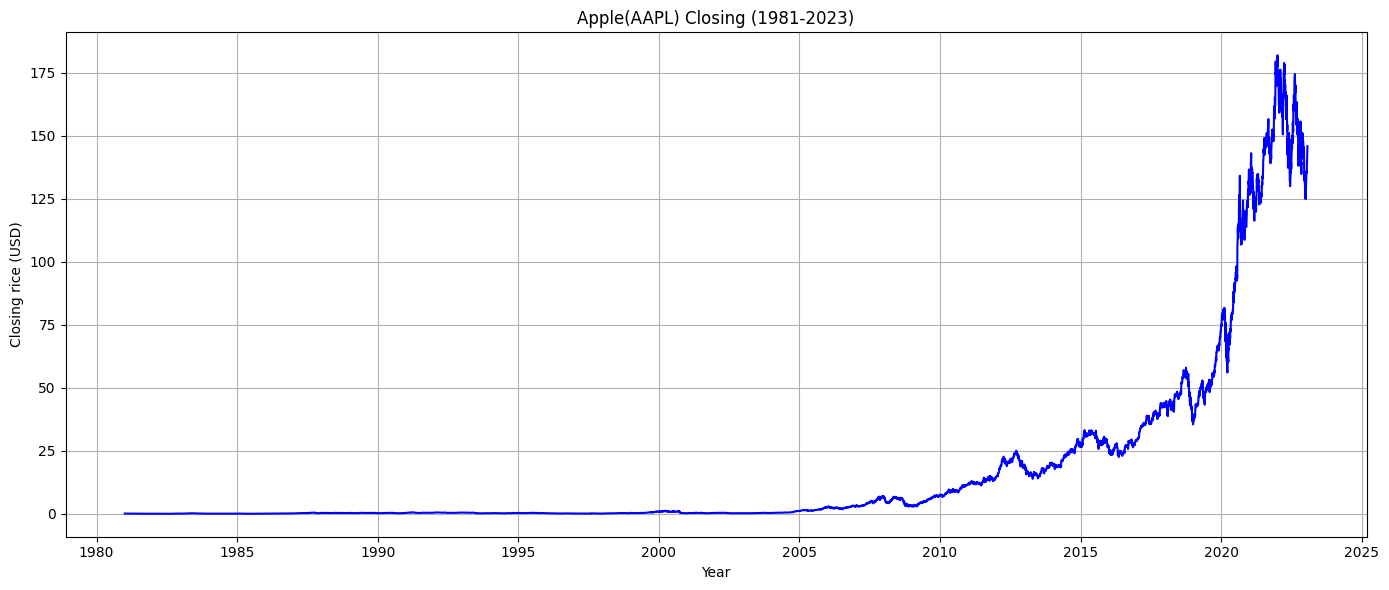

In [25]:
# Create a wide figure (good shape for a time series)

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Close"], label="Closing Price", color="blue")
plt.title("Apple(AAPL) Closing (1981-2023)")
plt.xlabel("Year")
plt.ylabel("Closing rice (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Import the candlestick plotting library

import mplfinance as mpf

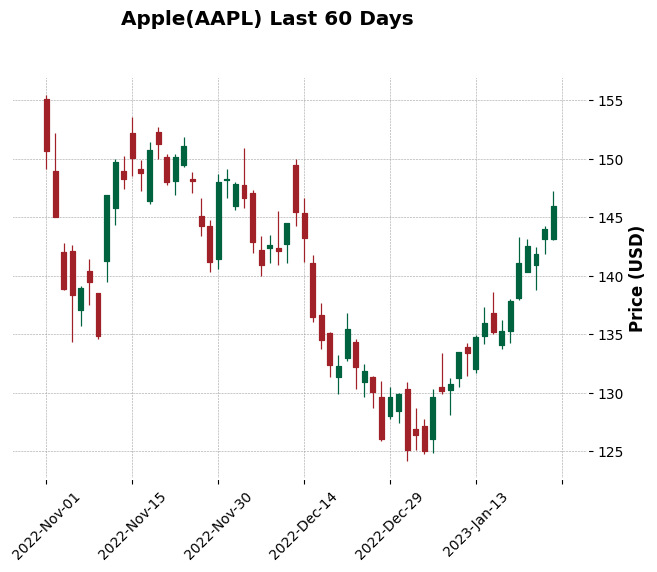

In [29]:
recent =df.tail(60)
mpf.plot(recent, type="candle", style="charles", title="Apple(AAPL) Last 60 Days", ylabel="Price (USD)")

In [30]:
# Compute key descriptive statistics (mean, median, std) for the main columns
df[["Open", "High", "Low", "Close", "Volume"]].agg(["mean", "median", "std"])

,Open,High,Low,Close,Volume
mean,16.689173,16.879955,16.500822,16.697362,3.275098e+08
median,0.488839,0.495536,0.480446,0.487701,2.145976e+08
std,35.450519,35.882848,35.031289,35.473912,3.378203e+08


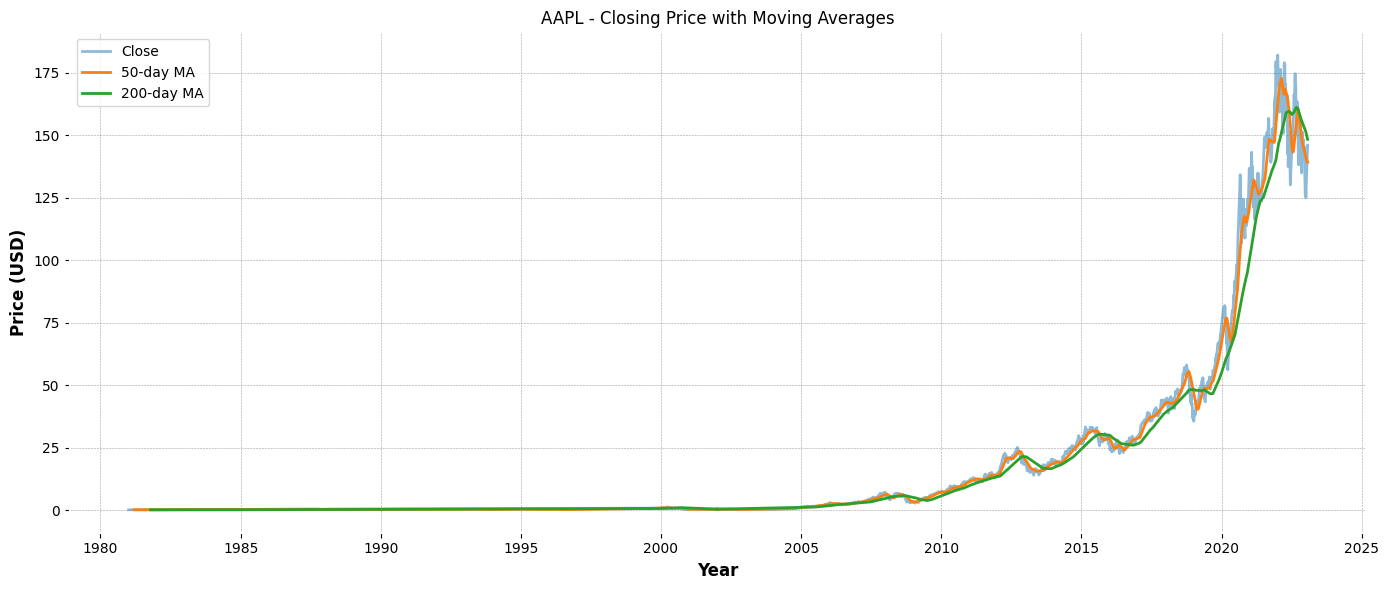

In [31]:
# Compute two moving averages of the closing price
# A 50-day window reacts faster; a 200-day window shows the long-term trend
df["MA50"] = df["Close"].rolling(window=50).mean()
df["MA200"] = df["Close"].rolling(window=200).mean()

# Plot the closing price together with its moving averages
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Close"], label="Close", alpha=0.5)
plt.plot(df.index, df["MA50"], label="50-day MA")
plt.plot(df.index, df["MA200"], label="200-day MA")

plt.title("AAPL - Closing Price with Moving Averages")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
# Select the daily closing prices for two different years
close_2020 = df.loc["2020", "Close"]
close_2021 = df.loc["2021", "Close"]

# Independent two-sample t-test: are the two yearly means significantly different?
t_stat, p_value = stats.ttest_ind(close_2020, close_2021)

print("t-statistic:", t_stat)
print("p-value:", p_value)

# Interpret the result against the 0.05 threshold
alpha = 0.05
if p_value < alpha:
    print("Significant difference between 2020 and 2021 (reject H0).")
else:
    print("No significant difference (fail to reject H0).")

t-statistic: -27.588625391847753
p-value: 1.0094191871894163e-102
Significant difference between 2020 and 2021 (reject H0).


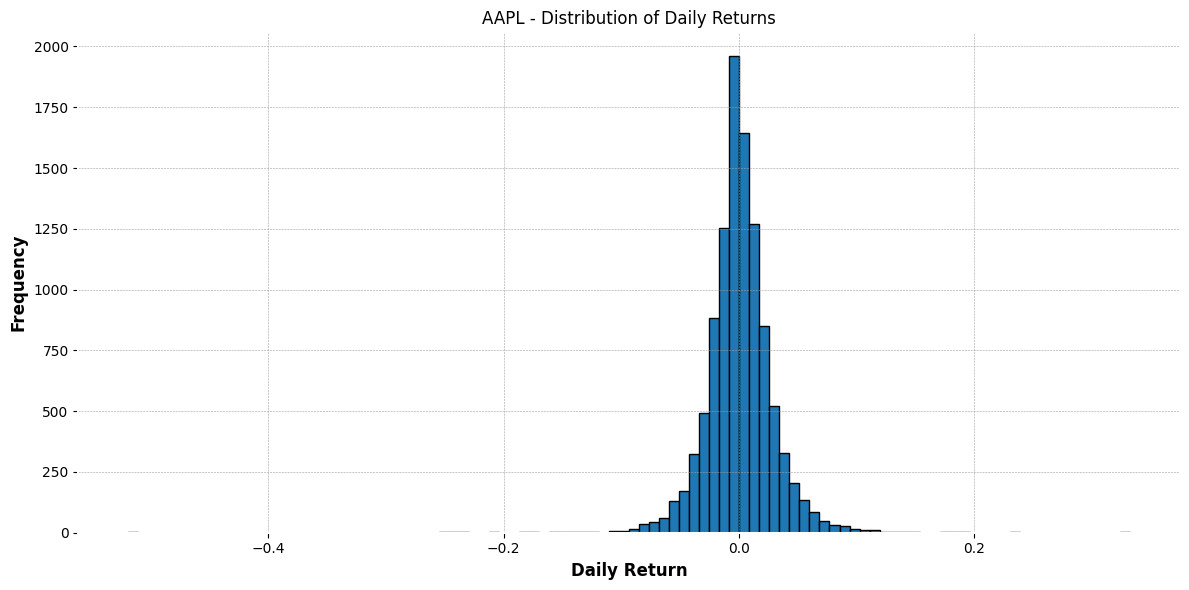

Normality test statistic: 2719.205287365935
p-value: 0.0
Daily returns are NOT normally distributed (reject H0).


In [33]:
# Compute daily returns: percentage change of the closing price day over day
df["Daily_Return"] = df["Close"].pct_change()

# Plot the distribution of the daily returns
plt.figure(figsize=(12, 6))
plt.hist(df["Daily_Return"].dropna(), bins=100, edgecolor="black")
plt.title("AAPL - Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

# Test whether the daily returns follow a normal distribution (D'Agostino-Pearson)
returns = df["Daily_Return"].dropna()
stat, p_value = stats.normaltest(returns)

print("Normality test statistic:", stat)
print("p-value:", p_value)

# Interpret
alpha = 0.05
if p_value < alpha:
    print("Daily returns are NOT normally distributed (reject H0).")
else:
    print("Daily returns look normally distributed (fail to reject H0).")

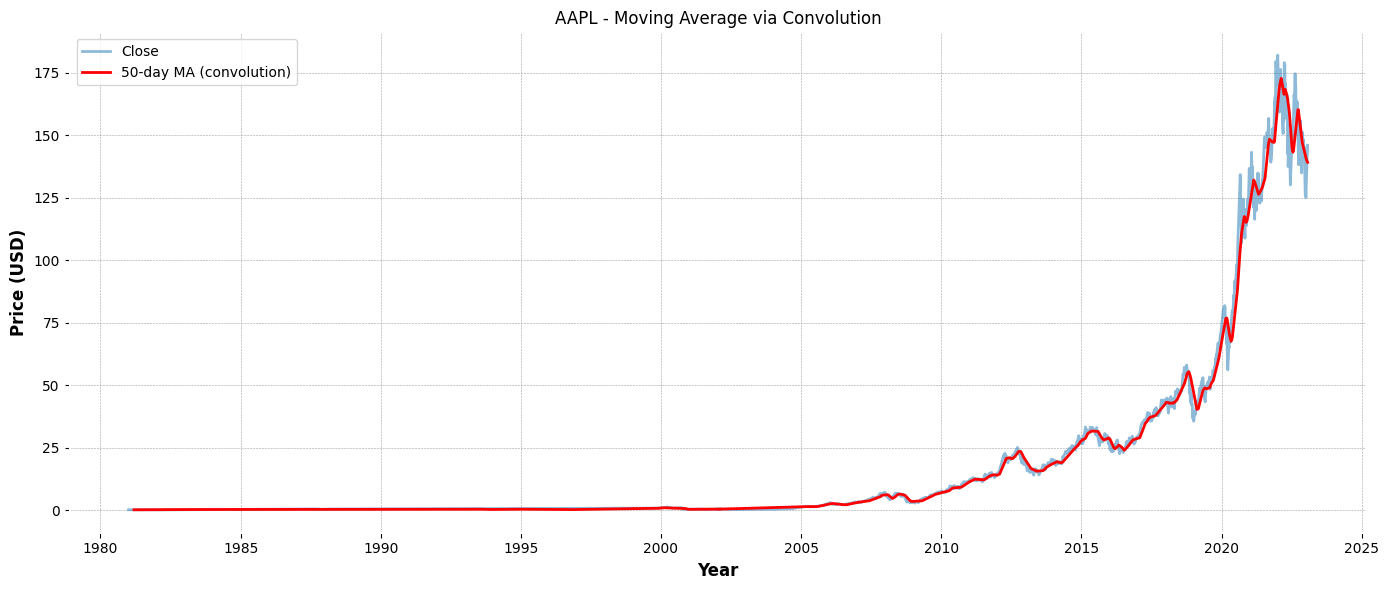

In [34]:
# Define the window and a uniform averaging kernel (N values, each equal to 1/N)
window = 50
kernel = np.ones(window) / window

# Convolve the closing price with the kernel -> this IS a moving average
close_values = df["Close"].values
ma_convolve = np.convolve(close_values, kernel, mode="valid")

# Align the convolution output with the correct dates and plot it
ma_dates = df.index[window - 1:]

plt.figure(figsize=(14, 6))
plt.plot(df.index, close_values, label="Close", alpha=0.5)
plt.plot(ma_dates, ma_convolve, label="50-day MA (convolution)", color="red")
plt.title("AAPL - Moving Average via Convolution")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
# Keep only rows where MA50 exists (drop the first NaN values), aligned with Volume
data = df[["MA50", "Volume"]].dropna()

# np.corrcoef returns a 2x2 correlation matrix
corr_matrix = np.corrcoef(data["MA50"], data["Volume"])
print("Correlation matrix:\n", corr_matrix)

# The off-diagonal value is the correlation coefficient between the two series
print("Correlation MA50 vs Volume:", corr_matrix[0, 1])

Correlation matrix:
 [[ 1.         -0.21558721]
 [-0.21558721  1.        ]]
Correlation MA50 vs Volume: -0.21558721076896753


In [36]:
# Full correlation matrix between the main indicators
df[["Close", "MA50", "MA200", "Volume", "Daily_Return"]].corr()

,Close,MA50,MA200,Volume,Daily_Return
Close,1.000000,0.996672,0.989792,-0.214933,0.002827
MA50,0.996672,1.000000,0.994879,-0.215587,-0.003909
MA200,0.989792,0.994879,1.000000,-0.223314,-0.004147
Volume,-0.214933,-0.215587,-0.223314,1.000000,0.001475
Daily_Return,0.002827,-0.003909,-0.004147,0.001475,1.000000


In [ ]:

#  SUMMARY AND INSIGHTS

#
# DATASET
# - Apple Inc. (AAPL) daily stock prices from 1981-01-02 to 2023-01-27.
# - 10,608 trading days; columns: Open, High, Low, Close, Adj Close, Volume.
# - No missing values were found.
#
# PRICE TRAJECTORY
# - The closing price stayed almost flat (well below $1, split-adjusted) for
#   roughly 25 years, then grew exponentially from ~2005 onward (iPod/iPhone
#   era), reaching an all-time high of $182.01.
#
# DESCRIPTIVE STATISTICS (Close)
# - Mean = $16.70 but Median = $0.49 -> a very large gap.
# - This reveals a strong right-skew: more than half of the trading days
#   occurred before ~2005 at very low prices, while the mean is pulled up by
#   the recent high prices. Standard deviation = $35.47.
#
# MOVING AVERAGES
# - The 50-day and 200-day moving averages confirm the long-term uptrend.
# - They correlate ~0.99 with the price, which is expected since a moving
#   average is just a smoothed version of the price.
#
# HYPOTHESIS TEST (t-test: mean Close 2020 vs 2021)
# - Mean 2020 = $95.35, Mean 2021 = $140.99.
# - t = -27.59, p-value = 1.0e-102 (far below 0.05).
# - Conclusion: the difference is highly significant; the stock traded
#   significantly higher in 2021 than in 2020 (reject H0).
#
# DAILY RETURNS AND NORMALITY
# - Average daily return = +0.105%; daily volatility (std) = 2.82%.
# - D'Agostino-Pearson normality test: p-value ~ 0 -> returns are NOT normal.
# - Excess kurtosis = 18.1 (normal = 0): very "fat tails", i.e. extreme daily
#   moves are far more frequent than a normal distribution predicts.
# - Slight negative skew (-0.375): sharp drops are a bit more pronounced.
#
# CORRELATIONS
# - Price vs moving averages ~ 0.99 (trivial: MAs are smoothed price).
# - Volume vs price ~ -0.22: weak and negative, and confounded by stock splits
#   and the long-term trend, so correlation != causation.
# - Daily returns vs everything ~ 0: returns are essentially uncorrelated with
#   the price level or volume, consistent with random-walk behaviour.

In [ ]:

#  REFLECTION

#
# CHALLENGES ENCOUNTERED AND SOLUTIONS
#
# 1. Date parsing
#    - Dates were in DD/MM/YYYY (European) format, but pandas defaults to the
#      US MM/DD order and was misreading them.
#    - Solution: pd.read_csv(..., parse_dates=["Date"], dayfirst=True), then
#      set Date as the index and sort chronologically.
#
# 2. Missing libraries
#    - SciPy (statistical tests) and mplfinance (candlestick chart) were not
#      installed in the notebook's Python.
#    - Solution: installed them from inside the notebook with
#      !{sys.executable} -m pip install ..., targeting the exact kernel.
#
# 3. Unreadable candlestick chart
#    - A candlestick over the full 42 years (10,608 candles) is unreadable.
#    - Solution: zoomed in on the last 60 trading days (df.tail(60)).
#
# 4. Choosing the right normality test
#    - With 10,608 returns, Shapiro-Wilk is unreliable (intended for n <= 5000).
#    - Solution: used D'Agostino-Pearson (scipy.stats.normaltest), suitable for
#      large samples.
#
# 5. Interpreting correlations responsibly
#    - The negative price-volume correlation is weak and confounded by stock
#      splits and the long-term trend, so it was not read as causation.
#
# 6. t-test assumptions
#    - Daily prices within a year are autocorrelated, hence not strictly
#      independent. The conclusion is still clear given the large gap, but this
#      limitation is worth noting.
#
# KEY TAKEAWAY
# - Combining NumPy, Pandas, Matplotlib and SciPy makes it possible to load,
#   visualize and statistically test a long financial time series. The "fat
#   tails" of the returns are a clear reminder that real markets do not follow
#   a normal distribution.